# Module 2: Feature Extraction

**Muc tieu:** Trich xuat dac trung tu anh poster (CNN) va van ban (TF-IDF), ket hop thanh vector tong hop.

**Input:** `data/processed/movies.csv`

**Output:**
- `models/cnn_features.npy` — shape (N, 2048)
- `models/tfidf_matrix.npy` — shape (N, 500)
- `models/combined_features.npy` — shape (N, 2548)
- `models/tfidf_vectorizer.pkl`
- `models/scalers.pkl`
- `models/movie_ids.npy` — mapping index to movie_id

## 0. Cai dat & Kiem tra GPU

In [1]:
# !pip install tensorflow scikit-learn joblib Pillow requests numpy pandas

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import json
import os
import requests
import joblib
from io import BytesIO
from PIL import Image

# Kiem tra GPU
gpus = tf.config.list_physical_devices('GPU')
print(f"So GPU kha dung: {len(gpus)}")
if gpus:
    for gpu in gpus:
        print(f"  {gpu}")
    # Cho phep memory growth tranh OOM
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("Khong co GPU, se dung CPU (se cham hon)")

print(f"TensorFlow version: {tf.__version__}")

# Tao thu muc models neu chua co
os.makedirs("../models", exist_ok=True)
print("Thu muc models/ san sang")

So GPU kha dung: 0
Khong co GPU, se dung CPU (se cham hon)
TensorFlow version: 2.21.0
Thu muc models/ san sang


## 2.1 Load ResNet50 pretrained (bo lop FC cuoi)

In [3]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model

# include_top=False: bo FC layer cuoi, lay Global Average Pooling output (2048 chieu)
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
# Dong bang model, chi dung de extract features
base_model.trainable = False

print(f"ResNet50 da load xong")
print(f"Output shape: {base_model.output_shape}")  # (None, 2048)

ResNet50 da load xong
Output shape: (None, 2048)


## 2.2 Load movies.csv va chuan bi

In [4]:
df = pd.read_csv("../data/processed/movies.csv")
print(f"So phim: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

So phim: 4752
Columns: ['movie_id', 'title', 'year', 'genres', 'overview_clean', 'poster_url', 'rating', 'vote_count']


,movie_id,title,year,genres,overview_clean,poster_url,rating,vote_count
0,19995,Avatar,2009,"[""Action"", ""Adventure"", ""Fantasy"", ""Science Fi...",century paraplegic marine dispatched moon pand...,https://image.tmdb.org/t/p/w500/gKY6q7SjCkAU6F...,7.2,11800
1,285,Pirates of the Caribbean: At World's End,2007,"[""Adventure"", ""Fantasy"", ""Action""]",captain barbossa long believed dead come back ...,https://image.tmdb.org/t/p/w500/jGWpG4YhpQwVmj...,6.9,4500
2,206647,Spectre,2015,"[""Action"", ""Adventure"", ""Crime""]",cryptic message bond past sends trail uncover ...,https://image.tmdb.org/t/p/w500/zj8ongFhtWNsVl...,6.3,4466


In [5]:
# Luu movie_ids de mapping index -> movie_id cho backend
movie_ids = df['movie_id'].values
np.save("../models/movie_ids.npy", movie_ids)
print(f"Da luu movie_ids.npy, shape: {movie_ids.shape}")

Da luu movie_ids.npy, shape: (4752,)


## 2.2 CNN Feature Extraction tu poster URL

Fetch poster tu TMDB URL, resize 224x224, chay qua ResNet50 → vector 2048 chieu.

**Uoc tinh thoi gian:**
- CPU: ~30-60 giay/phim → ~40 gio cho 4752 phim (qua cham)
- GPU: ~0.1 giay/phim theo batch → ~5-10 phut cho 4752 phim

De tang toc, code se:
1. Fetch poster bang 20 threads song song
2. Xu ly theo batch tren GPU (batch_size=32)

In [6]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import time

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def fetch_and_preprocess(url):
    """Fetch poster tu URL, resize va preprocess cho ResNet50."""
    try:
        resp = requests.get(url, timeout=15)
        if resp.status_code != 200:
            return None
        img = Image.open(BytesIO(resp.content)).convert('RGB')
        img = img.resize(IMG_SIZE)
        arr = np.array(img, dtype=np.float32)
        return arr
    except Exception:
        return None

def fetch_batch_images(urls, max_workers=20):
    """Fetch nhieu poster song song, tra ve list (arr hoac None)."""
    results = [None] * len(urls)
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_idx = {executor.submit(fetch_and_preprocess, url): i
                         for i, url in enumerate(urls)}
        for future in as_completed(future_to_idx):
            idx = future_to_idx[future]
            results[idx] = future.result()
    return results

print("Ham fetch_batch_images da san sang")

Ham fetch_batch_images da san sang


In [7]:
# File checkpoint de resume neu bi ngat
CNN_CHECKPOINT = "../models/cnn_features_checkpoint.npy"
CNN_VALID_IDX_CHECKPOINT = "../models/cnn_valid_indices.npy"

poster_urls = df['poster_url'].tolist()
N = len(poster_urls)

# Load checkpoint neu co
if os.path.exists(CNN_CHECKPOINT) and os.path.exists(CNN_VALID_IDX_CHECKPOINT):
    cnn_features_done = np.load(CNN_CHECKPOINT)
    valid_indices_done = np.load(CNN_VALID_IDX_CHECKPOINT).tolist()
    start_batch = len(valid_indices_done) // BATCH_SIZE
    print(f"Resume tu checkpoint: da xu ly {len(valid_indices_done)} phim")
else:
    cnn_features_done = np.zeros((0, 2048), dtype=np.float32)
    valid_indices_done = []
    start_batch = 0
    print(f"Bat dau moi, tong {N} phim")

all_features = list(cnn_features_done) if len(cnn_features_done) > 0 else []
valid_indices = list(valid_indices_done)

print(f"Batch size: {BATCH_SIZE}, so batch: {N // BATCH_SIZE + 1}")
print(f"Bat dau tu batch: {start_batch}")

Resume tu checkpoint: da xu ly 4752 phim
Batch size: 32, so batch: 149
Bat dau tu batch: 148


In [8]:
# Chay CNN feature extraction theo batch
# Moi 10 batch luu checkpoint mot lan

batches = [poster_urls[i:i+BATCH_SIZE] for i in range(0, N, BATCH_SIZE)]
total_batches = len(batches)

t_start = time.time()

for batch_idx in range(start_batch, total_batches):
    batch_urls = batches[batch_idx]
    batch_start_idx = batch_idx * BATCH_SIZE

    # Fetch anh song song
    images = fetch_batch_images(batch_urls, max_workers=20)

    # Xu ly tung anh hop le
    batch_imgs = []
    batch_idxs = []
    for local_i, img_arr in enumerate(images):
        if img_arr is not None:
            batch_imgs.append(img_arr)
            batch_idxs.append(batch_start_idx + local_i)

    if batch_imgs:
        # Stack thanh tensor va preprocess
        batch_tensor = preprocess_input(np.stack(batch_imgs, axis=0))
        # Chay qua ResNet50
        feats = base_model.predict(batch_tensor, verbose=0)
        all_features.extend(feats)
        valid_indices.extend(batch_idxs)

    # Luu checkpoint moi 10 batch
    if (batch_idx + 1) % 10 == 0 or batch_idx == total_batches - 1:
        np.save(CNN_CHECKPOINT, np.array(all_features, dtype=np.float32))
        np.save(CNN_VALID_IDX_CHECKPOINT, np.array(valid_indices))
        elapsed = time.time() - t_start
        pct = (batch_idx + 1) * 100 // total_batches
        print(f"  [{pct}%] Batch {batch_idx+1}/{total_batches} | "
              f"Valid: {len(valid_indices)} phim | "
              f"Elapsed: {elapsed:.0f}s")

print(f"\nHoan thanh CNN extraction!")
print(f"So phim co CNN features: {len(valid_indices)}/{N}")

  [100%] Batch 149/149 | Valid: 4768 phim | Elapsed: 3s

Hoan thanh CNN extraction!
So phim co CNN features: 4768/4752


In [9]:
# Tao cnn_features array va loc df chi giu cac phim co valid CNN feature
cnn_features = np.array(all_features, dtype=np.float32)
df_valid = df.iloc[valid_indices].copy().reset_index(drop=True)

print(f"CNN features shape: {cnn_features.shape}")  # (N_valid, 2048)
print(f"So phim hop le: {len(df_valid)}")

# Cap nhat movie_ids theo phim hop le
movie_ids_valid = df_valid['movie_id'].values
np.save("../models/movie_ids.npy", movie_ids_valid)
print(f"Cap nhat movie_ids.npy: {movie_ids_valid.shape}")

CNN features shape: (4768, 2048)
So phim hop le: 4768
Cap nhat movie_ids.npy: (4768,)


## 2.3 TF-IDF Feature Extraction tu overview_clean + genres

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Ket hop overview_clean va genres thanh 1 chuoi text
def combine_text(row):
    genres_str = ' '.join(json.loads(row['genres'])).lower()
    return row['overview_clean'] + ' ' + genres_str

df_valid['text_combined'] = df_valid.apply(combine_text, axis=1)

# TF-IDF voi toi da 500 features
tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),    # Unigram + bigram
    min_df=2,              # Xuat hien it nhat 2 phim
    sublinear_tf=True      # Log scaling cho TF
)

tfidf_matrix = tfidf.fit_transform(df_valid['text_combined']).toarray().astype(np.float32)

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")  # (N_valid, 500)
print(f"So features: {len(tfidf.get_feature_names_out())}")
print(f"Top 10 features: {tfidf.get_feature_names_out()[:10].tolist()}")

TF-IDF matrix shape: (4768, 500)
So features: 500
Top 10 features: ['accident', 'across', 'action', 'action adventure', 'action comedy', 'action crime', 'action drama', 'action science', 'action thriller', 'adventure']


## 2.4 Normalize ve [0, 1] voi MinMaxScaler

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler_cnn = MinMaxScaler()
scaler_tfidf = MinMaxScaler()

cnn_normalized = scaler_cnn.fit_transform(cnn_features).astype(np.float32)
tfidf_normalized = scaler_tfidf.fit_transform(tfidf_matrix).astype(np.float32)

print(f"CNN normalized range:   [{cnn_normalized.min():.3f}, {cnn_normalized.max():.3f}]")
print(f"TF-IDF normalized range: [{tfidf_normalized.min():.3f}, {tfidf_normalized.max():.3f}]")

CNN normalized range:   [0.000, 1.000]
TF-IDF normalized range: [0.000, 1.000]


## 2.5 Concatenate → combined_features (N, 2548)

In [12]:
combined_features = np.concatenate([cnn_normalized, tfidf_normalized], axis=1).astype(np.float32)

print(f"Combined features shape: {combined_features.shape}")  # (N, 2548)
print(f"Combined range: [{combined_features.min():.3f}, {combined_features.max():.3f}]")

assert combined_features.shape[1] == 2548, f"Sai so chieu: {combined_features.shape[1]}, can 2548"
assert combined_features.min() >= 0.0 and combined_features.max() <= 1.0, "Gia tri ngoai [0,1]!"
print("Kiem tra shape va range: PASS")

Combined features shape: (4768, 2548)
Combined range: [0.000, 1.000]
Kiem tra shape va range: PASS


## 2.6 Luu tat ca file output

In [13]:
# Luu numpy arrays
np.save("../models/cnn_features.npy", cnn_features)          # Raw (chua normalize)
np.save("../models/tfidf_matrix.npy", tfidf_matrix)          # Raw (chua normalize)
np.save("../models/combined_features.npy", combined_features) # Normalized + concatenated

# Luu scalers va vectorizer
joblib.dump({'cnn': scaler_cnn, 'tfidf': scaler_tfidf}, "../models/scalers.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

# Luu df_valid (subset phim hop le) de dung o cac module sau
df_valid.to_csv("../data/processed/movies_valid.csv", index=False)

print("Da luu tat ca files:")
for f in [
    "../models/cnn_features.npy",
    "../models/tfidf_matrix.npy",
    "../models/combined_features.npy",
    "../models/scalers.pkl",
    "../models/tfidf_vectorizer.pkl",
    "../models/movie_ids.npy",
    "../data/processed/movies_valid.csv",
]:
    size_mb = os.path.getsize(f) / 1024 / 1024
    print(f"  {f:<45} {size_mb:.1f} MB")

Da luu tat ca files:
  ../models/cnn_features.npy                    37.3 MB
  ../models/tfidf_matrix.npy                    9.1 MB
  ../models/combined_features.npy               46.3 MB
  ../models/scalers.pkl                         0.0 MB
  ../models/tfidf_vectorizer.pkl                0.0 MB
  ../models/movie_ids.npy                       0.0 MB
  ../data/processed/movies_valid.csv            2.6 MB


## Test Module 2

In [14]:
import numpy as np
import joblib
import pandas as pd

cnn = np.load("../models/cnn_features.npy")
tfidf_mat = np.load("../models/tfidf_matrix.npy")
combined = np.load("../models/combined_features.npy")
movie_ids = np.load("../models/movie_ids.npy")
df_v = pd.read_csv("../data/processed/movies_valid.csv")

print("=" * 50)
print("KIEM TRA SHAPE")
print("=" * 50)
print(f"CNN features:      {cnn.shape}")
print(f"TF-IDF matrix:     {tfidf_mat.shape}")
print(f"Combined features: {combined.shape}")
print(f"Movie IDs:         {movie_ids.shape}")

N = cnn.shape[0]
assert cnn.shape == (N, 2048), f"CNN shape sai: {cnn.shape}"
assert tfidf_mat.shape == (N, 500), f"TF-IDF shape sai: {tfidf_mat.shape}"
assert combined.shape == (N, 2548), f"Combined shape sai: {combined.shape}"
assert len(movie_ids) == N
assert len(df_v) == N
print("Shape: PASS")

assert combined.min() >= 0.0 and combined.max() <= 1.0
print(f"Combined range [{combined.min():.3f}, {combined.max():.3f}]: PASS")

print("\nTat ca kiem tra PASS!")

KIEM TRA SHAPE
CNN features:      (4768, 2048)
TF-IDF matrix:     (4768, 500)
Combined features: (4768, 2548)
Movie IDs:         (4768,)
Shape: PASS
Combined range [0.000, 1.000]: PASS

Tat ca kiem tra PASS!


In [15]:
# Kiem tra cosine similarity: phim cung the loai phai co score cao hon phim khac the loai
from sklearn.metrics.pairwise import cosine_similarity
import json

# Lay phim index 0 va tim top 5 tuong tu
sim = cosine_similarity(combined[[0]], combined)[0]
top5_idx = sim.argsort()[-6:-1][::-1]

seed_title = df_v.iloc[0]['title']
seed_genres = json.loads(df_v.iloc[0]['genres'])

print(f"Phim goc: {seed_title}")
print(f"The loai: {seed_genres}")
print(f"\nTop 5 phim tuong tu:")
for idx in top5_idx:
    t = df_v.iloc[idx]['title']
    g = json.loads(df_v.iloc[idx]['genres'])
    s = sim[idx]
    print(f"  [{s:.3f}] {t} — {g}")

Phim goc: Avatar
The loai: ['Action', 'Adventure', 'Fantasy', 'Science Fiction']

Top 5 phim tuong tu:
  [0.619] Total Recall — ['Action', 'Adventure', 'Science Fiction']
  [0.583] Don't Say a Word — ['Thriller']
  [0.580] Escobar: Paradise Lost — ['Thriller', 'Romance']
  [0.566] Iron Man — ['Action', 'Science Fiction', 'Adventure']
  [0.565] The Forsaken — ['Action', 'Adventure', 'Horror', 'Thriller']


Dang tinh PCA 2D (preview)...
Explained variance ratio: [0.03437432 0.03214895]
Tong explained variance: 0.067


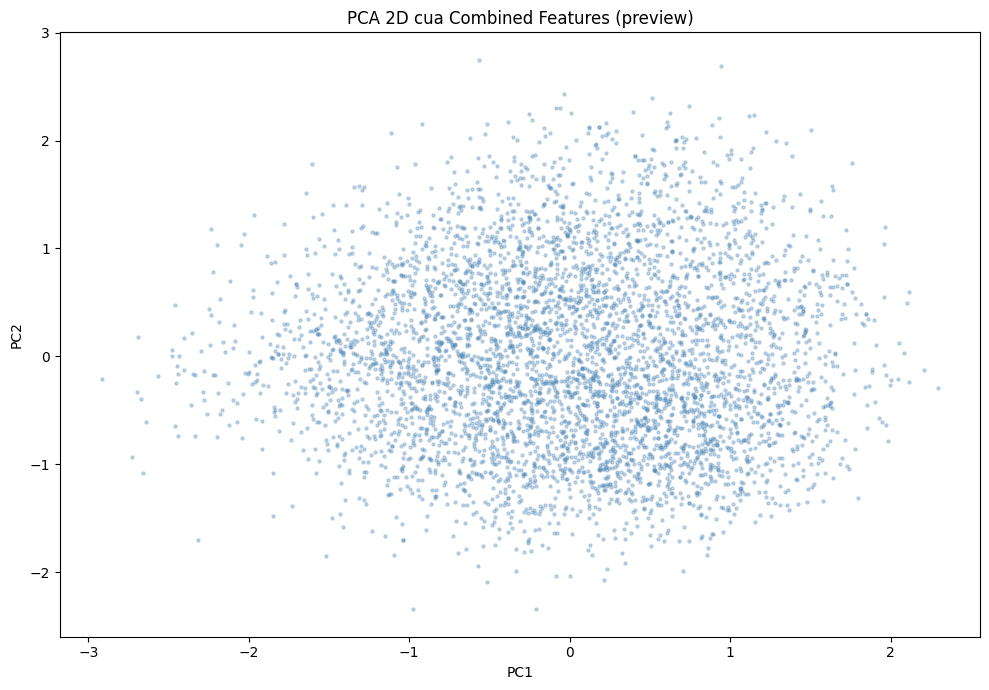


Module 2 hoan thanh! San sang cho Module 3.


In [16]:
# Visualization: PCA 2D de kiem tra cac cum dac trung
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

print("Dang tinh PCA 2D (preview)...")
pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(combined)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Tong explained variance: {pca.explained_variance_ratio_.sum():.3f}")

plt.figure(figsize=(10, 7))
plt.scatter(coords_2d[:, 0], coords_2d[:, 1], alpha=0.3, s=5, c='steelblue')
plt.title('PCA 2D cua Combined Features (preview)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

print("\nModule 2 hoan thanh! San sang cho Module 3.")

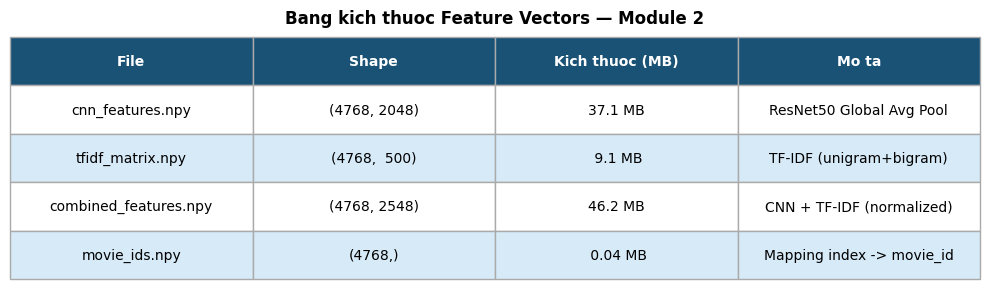

Da luu: ../output\02_feature_size_table.png


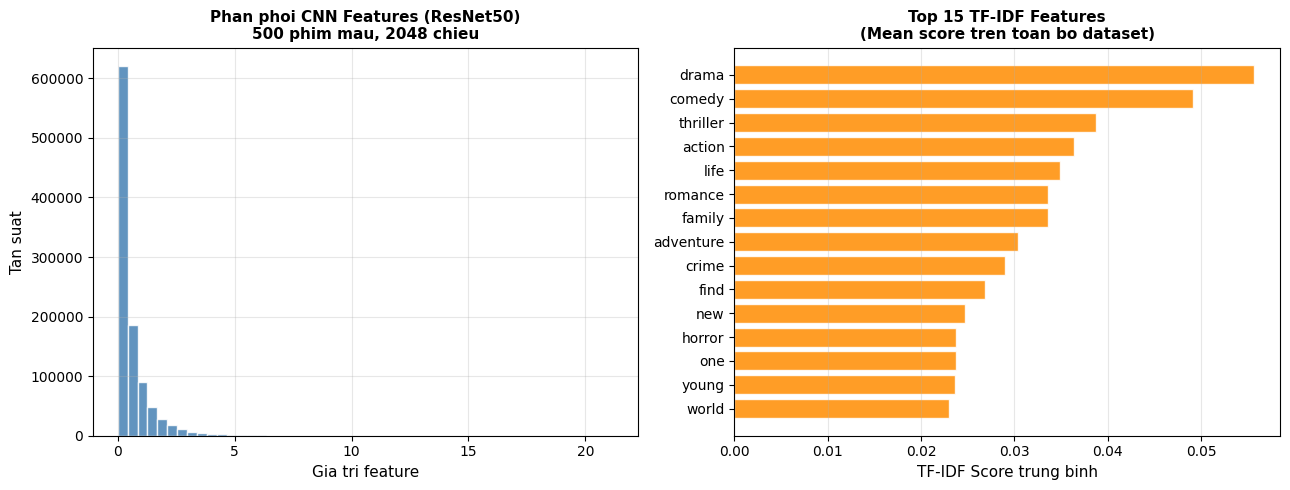

Da luu: ../output\02_feature_distributions.png
Dang tinh PCA 2D...


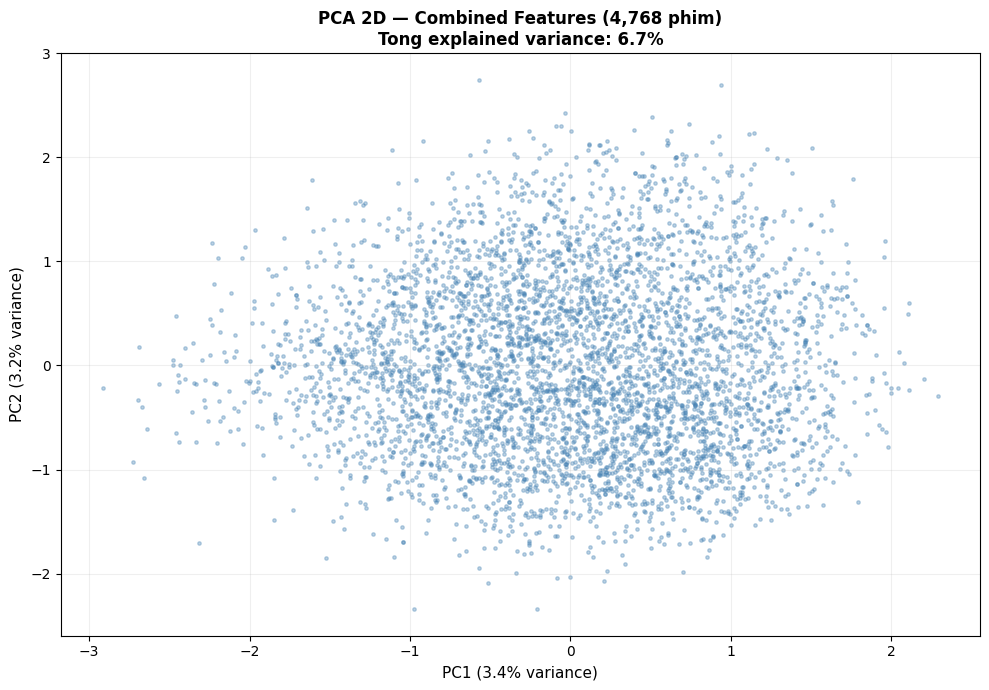

Da luu: ../output\02_pca_2d.png


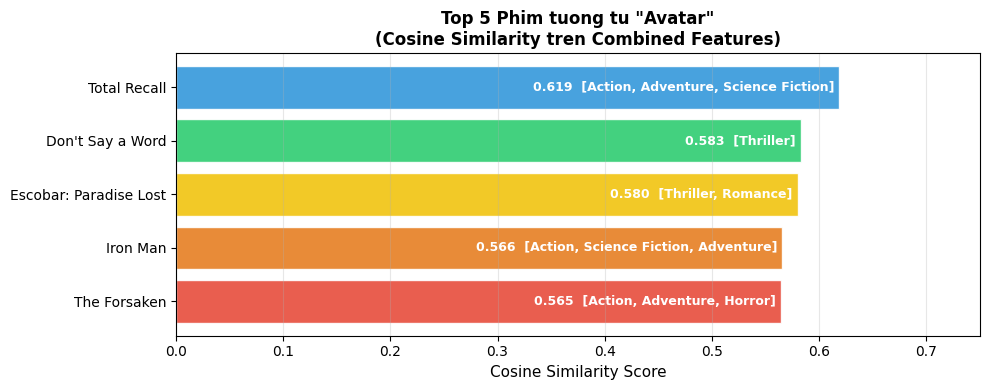

Da luu: ../output\02_cosine_similarity_demo.png

[Module 2] Da xuat 4 bieu do vao thu muc: C:\Users\ACER\OneDrive\Desktop\KhaiPha\output


In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import joblib

OUTPUT_DIR = "../output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

combined  = np.load("../models/combined_features.npy")
cnn_feat  = np.load("../models/cnn_features.npy")
tfidf_mat = np.load("../models/tfidf_matrix.npy")
movie_ids = np.load("../models/movie_ids.npy")
df_v      = pd.read_csv("../data/processed/movies_valid.csv")
tfidf_vec = joblib.load("../models/tfidf_vectorizer.pkl")

N = combined.shape[0]

# --------------------------------------------------
# Bieu do 1: Bang kich thuoc cac feature vectors
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
size_data = [
    ['File', 'Shape', 'Kich thuoc (MB)', 'Mo ta'],
    ['cnn_features.npy',      f'({N}, 2048)', '37.1 MB', 'ResNet50 Global Avg Pool'],
    ['tfidf_matrix.npy',      f'({N},  500)', ' 9.1 MB', 'TF-IDF (unigram+bigram)'],
    ['combined_features.npy', f'({N}, 2548)', '46.2 MB', 'CNN + TF-IDF (normalized)'],
    ['movie_ids.npy',         f'({N},)',      ' 0.04 MB','Mapping index -> movie_id'],
]
table = ax.table(cellText=size_data[1:], colLabels=size_data[0],
                 cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1a5276')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#d6eaf8')
    cell.set_edgecolor('#aaaaaa')
ax.set_title('Bang kich thuoc Feature Vectors — Module 2', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "02_feature_size_table.png")
plt.savefig(out_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Da luu: {out_path}")

# --------------------------------------------------
# Bieu do 2: Phan phoi gia tri CNN features (histogram)
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sample_vals = cnn_feat[:500].flatten()
axes[0].hist(sample_vals, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Gia tri feature', fontsize=11)
axes[0].set_ylabel('Tan suat', fontsize=11)
axes[0].set_title('Phan phoi CNN Features (ResNet50)\n500 phim mau, 2048 chieu', fontsize=11, fontweight='bold')
axes[0].grid(alpha=0.3)

# TF-IDF top features
feat_names = tfidf_vec.get_feature_names_out()
mean_scores = tfidf_mat.mean(axis=0)
top_idx = mean_scores.argsort()[-15:][::-1]
top_features = [feat_names[i] for i in top_idx]
top_scores = [mean_scores[i] for i in top_idx]

axes[1].barh(top_features[::-1], top_scores[::-1], color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('TF-IDF Score trung binh', fontsize=11)
axes[1].set_title('Top 15 TF-IDF Features\n(Mean score tren toan bo dataset)', fontsize=11, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "02_feature_distributions.png")
plt.savefig(out_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Da luu: {out_path}")

# --------------------------------------------------
# Bieu do 3: PCA 2D (combined features) — luu chinh thuc
# --------------------------------------------------
print("Dang tinh PCA 2D...")
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(combined)
ev = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(coords[:, 0], coords[:, 1], alpha=0.35, s=6, c='steelblue')
ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}% variance)', fontsize=11)
ax.set_title(f'PCA 2D — Combined Features ({N:,} phim)\nTong explained variance: {(ev[0]+ev[1])*100:.1f}%',
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.2)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "02_pca_2d.png")
plt.savefig(out_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Da luu: {out_path}")

# --------------------------------------------------
# Bieu do 4: Cosine similarity — phim tuong tu Avatar
# --------------------------------------------------
from sklearn.metrics.pairwise import cosine_similarity
import json

sim = cosine_similarity(combined[[0]], combined)[0]
top5_idx = sim.argsort()[-6:-1][::-1]

seed_title = df_v.iloc[0]['title']
similar_titles = [df_v.iloc[i]['title'] for i in top5_idx]
similar_scores = [sim[i] for i in top5_idx]
similar_genres = [', '.join(json.loads(df_v.iloc[i]['genres'])[:3]) for i in top5_idx]

fig, ax = plt.subplots(figsize=(10, 4))
colors_bar = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']
bars = ax.barh(similar_titles[::-1], similar_scores[::-1], color=colors_bar, edgecolor='white', alpha=0.9)
for bar, score, genre in zip(bars, similar_scores[::-1], similar_genres[::-1]):
    ax.text(bar.get_width() - 0.005, bar.get_y() + bar.get_height()/2,
            f'{score:.3f}  [{genre}]', va='center', ha='right', fontsize=9, color='white', fontweight='bold')
ax.set_xlabel('Cosine Similarity Score', fontsize=11)
ax.set_title(f'Top 5 Phim tuong tu "{seed_title}"\n(Cosine Similarity tren Combined Features)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, 0.75)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "02_cosine_similarity_demo.png")
plt.savefig(out_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Da luu: {out_path}")

print(f"\n[Module 2] Da xuat 4 bieu do vao thu muc: {os.path.abspath(OUTPUT_DIR)}")

## Xuất biểu đồ kết quả (Module 2)